In [1]:
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import yaml

from mejiro.utils import util

# read configuration file
config_file = os.path.join(os.path.expanduser('~'), 'mejiro', 'mejiro', 'data', 'mejiro_config', 'roman_data_challenge_rung_1.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '01a')
print(f'Data directory: {data_dir}')

Data directory: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/01a


In [2]:
# load all galaxy tables
table_paths = sorted(glob(os.path.join(data_dir, 'galaxy_table_*.pkl')))
print(f'Found {len(table_paths)} galaxy table(s)')

tables = []
for path in table_paths:
    tables.append(util.unpickle(path))

# inspect first table
t0 = tables[0]
print(f'\nKeys: {list(t0.keys())}')
print(f'Detector: {t0["detector"]}')
print(f'\nRed galaxies: {len(t0["red_galaxies"])} rows')
print(f'  Columns: {t0["red_galaxies"].colnames}')
print(f'\nBlue galaxies: {len(t0["blue_galaxies"])} rows')
print(f'  Columns: {t0["blue_galaxies"].colnames}')

if 'halo_galaxies' in t0:
    print(f'\nHalo galaxies: {len(t0["halo_galaxies"])} rows')
    print(f'  Columns: {t0["halo_galaxies"].colnames}')

Found 10 galaxy table(s)

Keys: ['red_galaxies', 'blue_galaxies', 'detector', 'halo_galaxies']
Detector: 1

Red galaxies: 44986 rows
  Columns: ['z', 'M', 'coeff', 'ellipticity', 'physical_size', 'stellar_mass', 'angular_size', 'mag_F062', 'mag_F087', 'mag_F106', 'mag_F129', 'mag_F158', 'mag_F184', 'mag_F146', 'mag_F213']

Blue galaxies: 748943 rows
  Columns: ['z', 'M', 'coeff', 'ellipticity', 'physical_size', 'stellar_mass', 'angular_size', 'mag_F062', 'mag_F087', 'mag_F106', 'mag_F129', 'mag_F158', 'mag_F184', 'mag_F146', 'mag_F213']

Halo galaxies: 161086 rows
  Columns: ['z', 'halo_mass', 'halo_mass_acc', 'e_h', 'p_h', 'concentration', 'stellar_mass', 'ellipticity', 'p_g', 'tb', 'angular_size', 'mag_F062', 'mag_F087', 'mag_F106', 'mag_F129', 'mag_F158', 'mag_F184', 'mag_F146', 'mag_F213']


In [3]:
# summary statistics across all tables
print(f'{"Table":<8} {"Detector":<10} {"Red":<10} {"Blue":<12} {"Halo":<10}')
print('-' * 50)
for i, t in enumerate(tables):
    n_halo = len(t['halo_galaxies']) if 'halo_galaxies' in t else 0
    print(f'{i:<8} {str(t["detector"]):<10} {len(t["red_galaxies"]):<10} {len(t["blue_galaxies"]):<12} {n_halo:<10}')

Table    Detector   Red        Blue         Halo      
--------------------------------------------------
0        1          44986      748943       161086    
1        2          44905      746520       162424    
2        3          44927      748425       161829    
3        4          45074      748091       161265    
4        5          45321      748260       161704    
5        6          45311      747054       162386    
6        7          45043      746229       160923    
7        8          44966      748028       161358    
8        9          44806      746305       161455    
9        10         44741      747288       161822    


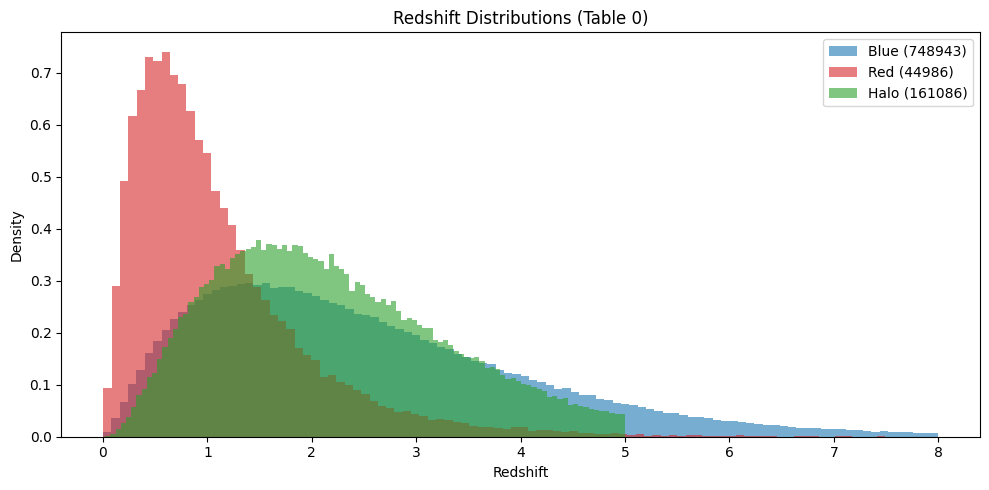

In [4]:
# redshift distributions (from first table)
red = t0['red_galaxies']
blue = t0['blue_galaxies']
has_halo = 'halo_galaxies' in t0

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(blue['z'], bins=100, alpha=0.6, label=f'Blue ({len(blue)})', color='C0', density=True)
ax.hist(red['z'], bins=100, alpha=0.6, label=f'Red ({len(red)})', color='C3', density=True)
if has_halo:
    halo = t0['halo_galaxies']
    ax.hist(halo['z'], bins=100, alpha=0.6, label=f'Halo ({len(halo)})', color='C2', density=True)
ax.set_xlabel('Redshift')
ax.set_ylabel('Density')
ax.set_title('Redshift Distributions (Table 0)')
ax.legend()
plt.tight_layout()
plt.show()

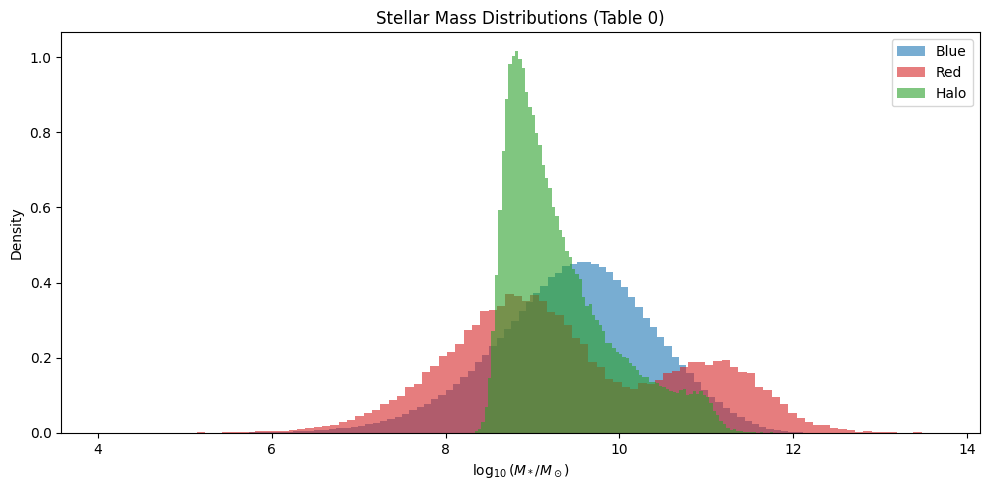

In [5]:
# stellar mass distributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(blue['stellar_mass']), bins=100, alpha=0.6, label='Blue', color='C0', density=True)
ax.hist(np.log10(red['stellar_mass']), bins=100, alpha=0.6, label='Red', color='C3', density=True)
if has_halo:
    ax.hist(np.log10(halo['stellar_mass']), bins=100, alpha=0.6, label='Halo', color='C2', density=True)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_ylabel('Density')
ax.set_title('Stellar Mass Distributions (Table 0)')
ax.legend()
plt.tight_layout()
plt.show()

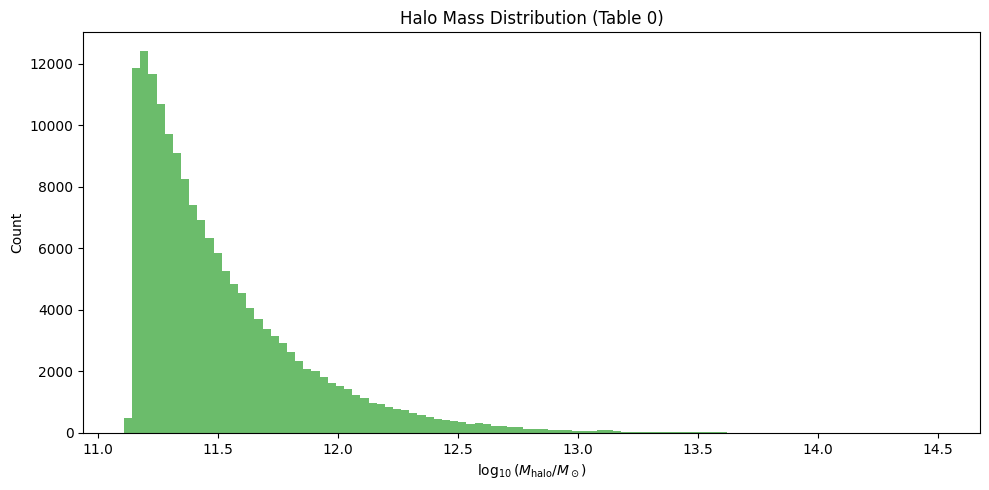

In [6]:
# halo mass distribution
if has_halo:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.log10(halo['halo_mass']), bins=100, alpha=0.7, color='C2')
    ax.set_xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
    ax.set_ylabel('Count')
    ax.set_title('Halo Mass Distribution (Table 0)')
    plt.tight_layout()
    plt.show()
else:
    print('No halo galaxies in this table')

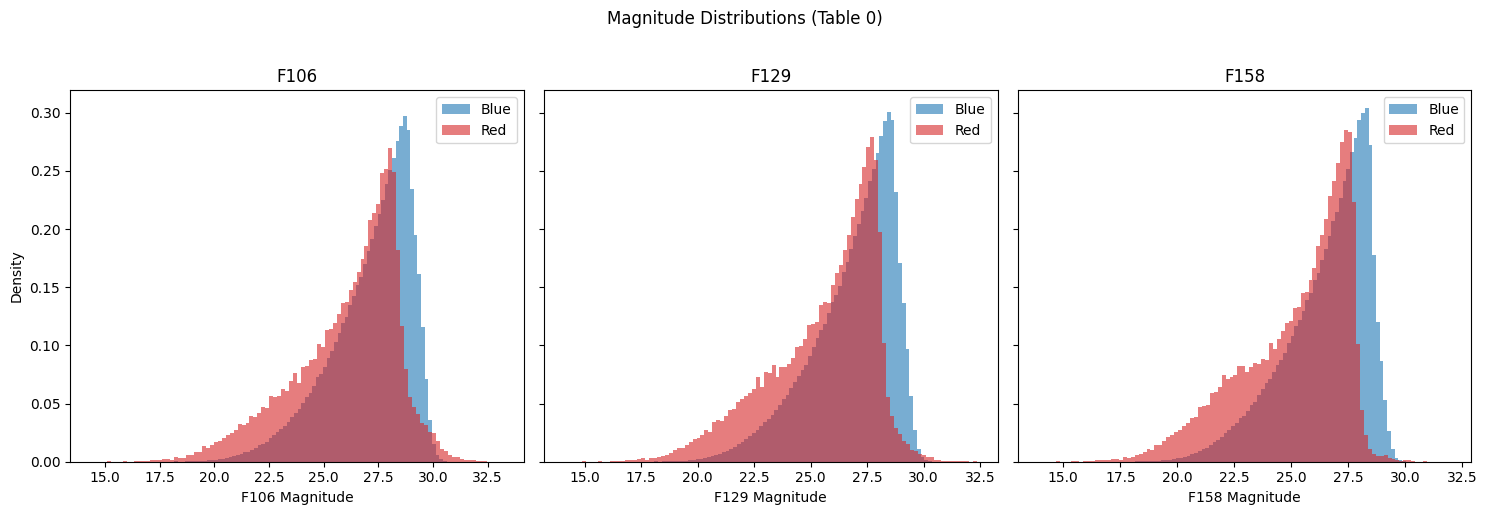

In [7]:
# magnitude distributions for key bands
bands_to_plot = ['F106', 'F129', 'F158']

fig, axes = plt.subplots(1, len(bands_to_plot), figsize=(5 * len(bands_to_plot), 5), sharey=True)
for ax, band in zip(axes, bands_to_plot):
    col = f'mag_{band}'
    ax.hist(blue[col], bins=100, alpha=0.6, label='Blue', color='C0', density=True)
    ax.hist(red[col], bins=100, alpha=0.6, label='Red', color='C3', density=True)
    ax.set_xlabel(f'{band} Magnitude')
    ax.set_title(band)
    ax.legend()
axes[0].set_ylabel('Density')
fig.suptitle('Magnitude Distributions (Table 0)', y=1.02)
plt.tight_layout()
plt.show()

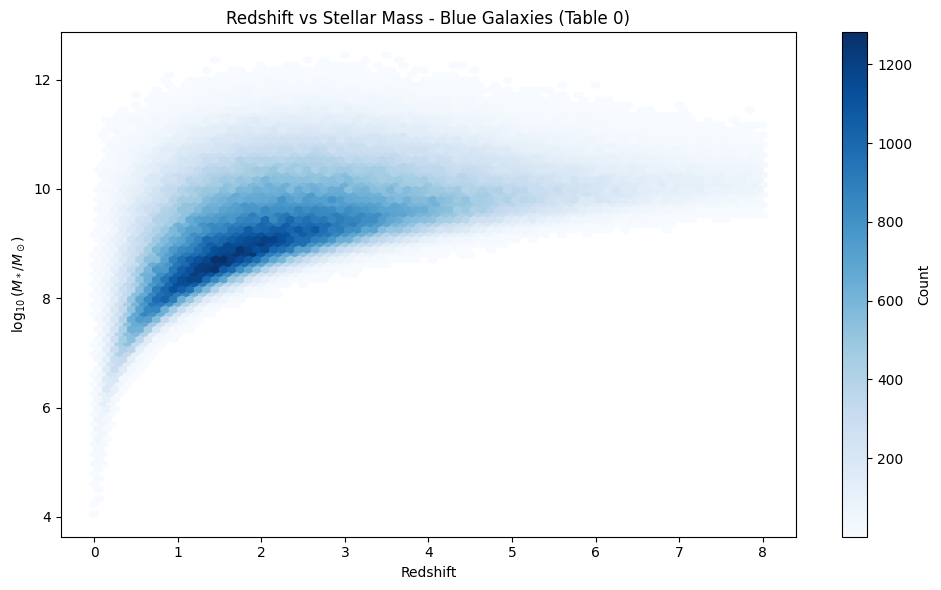

In [8]:
# redshift vs stellar mass (blue galaxies, table 0)
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(blue['z'], np.log10(blue['stellar_mass']), gridsize=80, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel('Redshift')
ax.set_ylabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_title('Redshift vs Stellar Mass - Blue Galaxies (Table 0)')
plt.tight_layout()
plt.show()

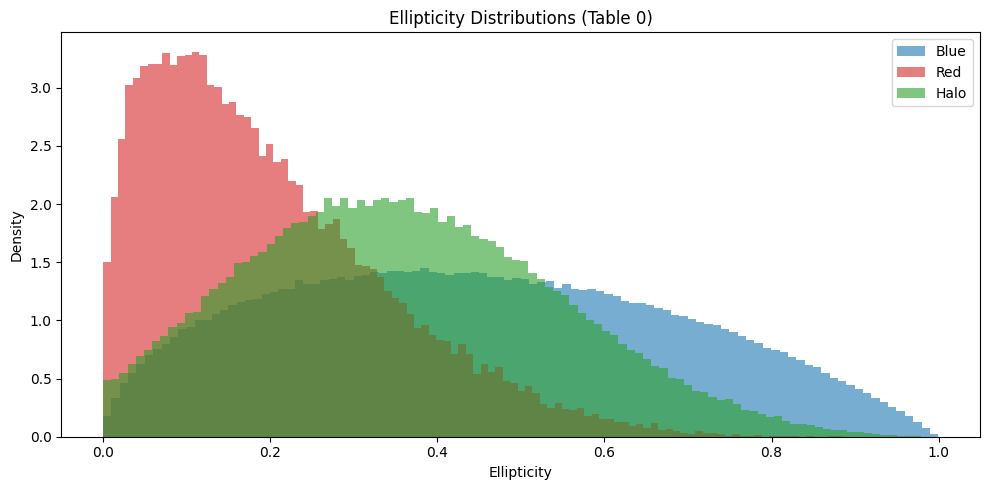

In [9]:
# ellipticity distributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(blue['ellipticity'], bins=100, alpha=0.6, label='Blue', color='C0', density=True)
ax.hist(red['ellipticity'], bins=100, alpha=0.6, label='Red', color='C3', density=True)
if has_halo:
    ax.hist(halo['ellipticity'], bins=100, alpha=0.6, label='Halo', color='C2', density=True)
ax.set_xlabel('Ellipticity')
ax.set_ylabel('Density')
ax.set_title('Ellipticity Distributions (Table 0)')
ax.legend()
plt.tight_layout()
plt.show()

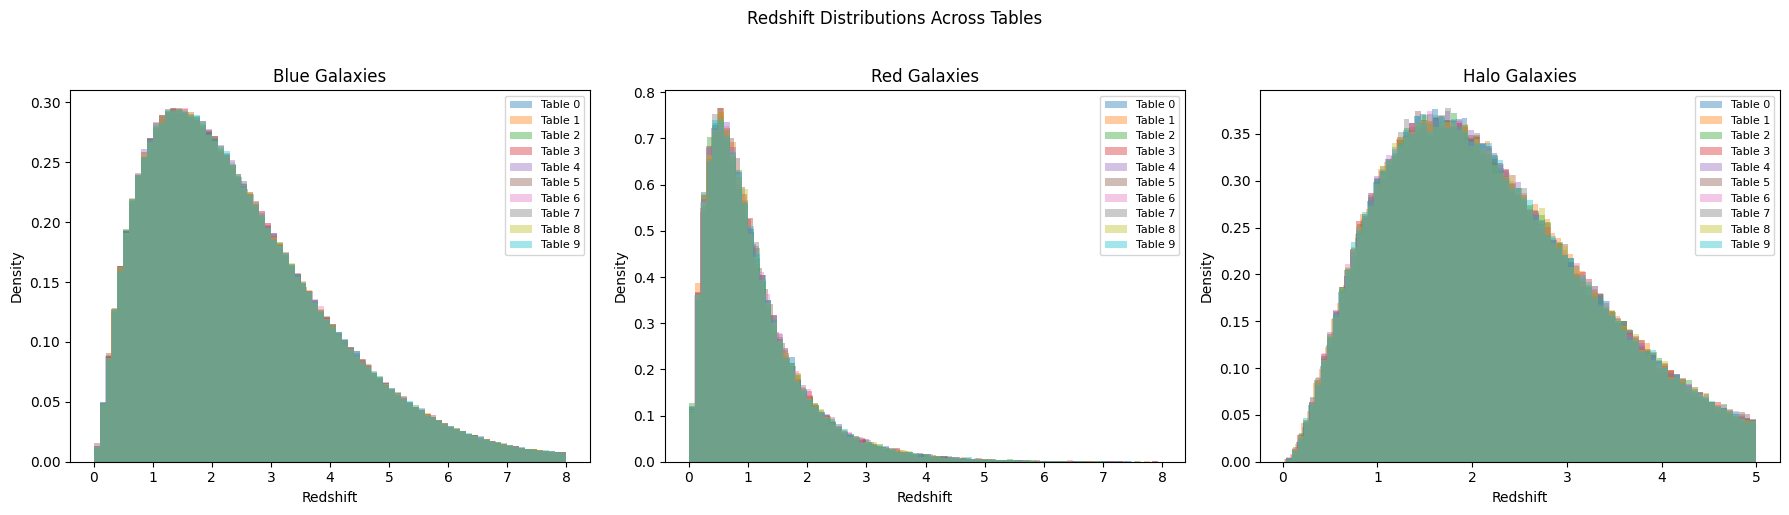

In [10]:
# cross-table comparison: overlay redshift distributions from multiple tables
if len(tables) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['Blue Galaxies', 'Red Galaxies', 'Halo Galaxies']
    keys = ['blue_galaxies', 'red_galaxies', 'halo_galaxies']
    
    for ax, title, key in zip(axes, titles, keys):
        for i, t in enumerate(tables):
            if key not in t:
                continue
            ax.hist(t[key]['z'], bins=80, alpha=0.4, density=True, label=f'Table {i}')
        ax.set_xlabel('Redshift')
        ax.set_ylabel('Density')
        ax.set_title(title)
        ax.legend(fontsize=8)
    
    fig.suptitle('Redshift Distributions Across Tables', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Only 1 table available; skipping cross-table comparison')

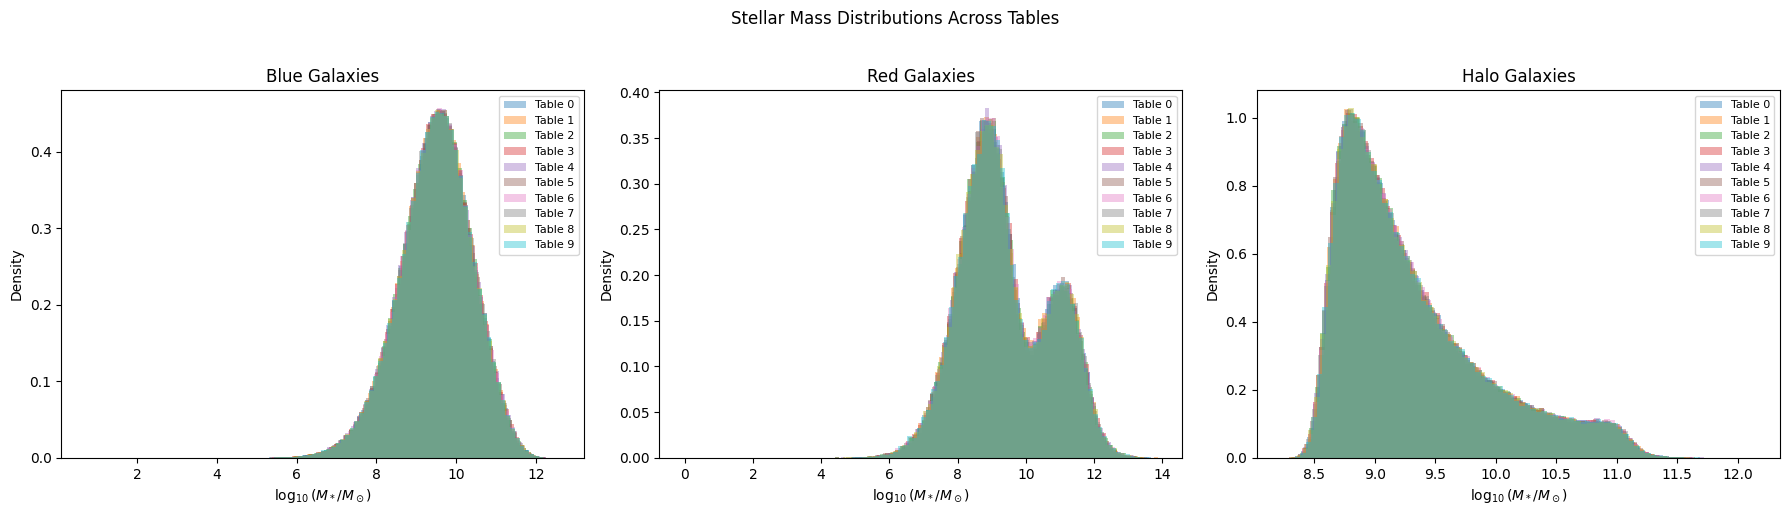

In [11]:
# cross-table comparison: stellar mass distributions
if len(tables) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = ['Blue Galaxies', 'Red Galaxies', 'Halo Galaxies']
    keys = ['blue_galaxies', 'red_galaxies', 'halo_galaxies']
    
    for ax, title, key in zip(axes, titles, keys):
        for i, t in enumerate(tables):
            if key not in t:
                continue
            ax.hist(np.log10(t[key]['stellar_mass']), bins=80, alpha=0.4, density=True, label=f'Table {i}')
        ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
        ax.set_ylabel('Density')
        ax.set_title(title)
        ax.legend(fontsize=8)
    
    fig.suptitle('Stellar Mass Distributions Across Tables', y=1.02)
    plt.tight_layout()
    plt.show()